Nombre: Felipe Aravena
Rut: 21.128.400-5
Fecha: 10-06-2026

In [16]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import json

In [41]:
#Ejercicio 1: Primera conexión a una API publica
#Paso 2
url = "https://api.open-meteo.com/v1/forecast"  
 
params = {  
    "latitude":        -33.45,  
    "longitude":       -70.65,    
    "current_weather": True  
} 
 

response = requests.get(url, params=params, timeout= 10) 
response.raise_for_status()   # Lanza excepción si el código es >= 400  
 
data = response.json() 
print(f"Codigo de estado : {response.status_code}")  
print(f"URL final        : {response.url}")  
print(f"Clima actual     : {data['current_weather']}")  

Codigo de estado : 200
URL final        : https://api.open-meteo.com/v1/forecast?latitude=-33.45&longitude=-70.65&current_weather=True
Clima actual     : {'time': '2026-06-10T15:45', 'interval': 900, 'temperature': 9.5, 'windspeed': 3.9, 'winddirection': 24, 'is_day': 1, 'weathercode': 53}


In [22]:
#Paso 3
#Explorar el JSON antes de procesarlo 
print("\nClaves principales:", list(data.keys()))  
 
#Ver el JSON formateado
print(json.dumps(data, indent=4))



Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_weather_units', 'current_weather']
{
    "latitude": -33.427067,
    "longitude": -70.64276,
    "generationtime_ms": 0.13017654418945312,
    "utc_offset_seconds": 0,
    "timezone": "GMT",
    "timezone_abbreviation": "GMT",
    "elevation": 554.0,
    "current_weather_units": {
        "time": "iso8601",
        "interval": "seconds",
        "temperature": "\u00b0C",
        "windspeed": "km/h",
        "winddirection": "\u00b0",
        "is_day": "",
        "weathercode": "wmo code"
    },
    "current_weather": {
        "time": "2026-06-10T15:15",
        "interval": 900,
        "temperature": 8.9,
        "windspeed": 4.7,
        "winddirection": 50,
        "is_day": 1,
        "weathercode": 53
    }
}


Preguntas de reflexión 

¿Qué ocurre si cambias timeout=10 por timeout=0?00001? ¿Qué excepción se lanza?
Nos lanza errores como: 'Attempted to set connect timeout to 0, but the timeout cannot be set to a value less than or equal to 0.' o 'leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers' 

¿Qué diferencia hay entre response?text y response.json()?
response.text entrega la respuesta cruda como un texto plano (str). response.json() toma ese texto y lo transforma automáticamente en un diccionario o lista ejecutable de Python.

Identifica en response.url como fueron codificados los parámetros que pasaste en params.
Los parámetros se anexaron al final de la URL usando ?, vinculando pares con = y separándolos mediante &. Además, el valor True de Python se convirtió automáticamente en true y el signo negativo de la latitud (-) se codificó como %2D

In [28]:
#Ejercicio 2: Manejo de errores y resiliencia
#Paso1
def get_seguro(url, params=None, timeout=10):
    """
    GET robusto con manejo de errores.
    Retorna el dict JSON o None si ocurre cualquier error.
    """
    try:
        # Completando el espacio en blanco con los argumentos requeridos
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondio en {timeout}s")
    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")
        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Limite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print("No autorizado. Verificar API key.")
    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexion o host invalido")
    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")
    return None


In [27]:
#Paso 2
# Caso 1: URL valida — debe retornar datos
r1 = get_seguro(
"https://api.open-meteo.com/v1/forecast",
params={"latitude": -33.45, "longitude": -70.65, "current_weather": True}
)
print("Caso 1 (valido):", r1["current_weather"] if r1 else "None")
# Caso 2: Endpoint inexistente — debe mostrar error 404
r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2 (404):", r2)
# Caso 3: Timeout muy bajo — debe mostrar error de timeout
r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3 (timeout):", r3)

[ERROR] Timeout: la API no respondio en 10s
Caso 1 (valido): None
[ERROR] Timeout: la API no respondio en 10s
Caso 2 (404): None
[ERROR] Timeout: la API no respondio en 1e-05s
Caso 3 (timeout): None


(a) Porque es obligatorio usar timeout
Evita que el programa se quede colgado indefinidamente esperando una respuesta si el servidor de la API se cae o la red falla, forzando un cierre controlado tras cumplirse el tiempo límite.

(b) Qué hace raise_for_status():
Verifica de forma automática el código HTTP de la respuesta; si detecta un código de error de cliente (4xx) o de servidor (5xx), detiene el flujo levantando una excepción de tipo HTTPError.

(c) Cuándo usarías cada excepción:

Timeout: Cuando la API tarda demasiado en responder debido a sobrecarga en el servidor o lentitud extrema en la red.

HTTPError: Cuando la conexión física es exitosa, pero el servidor devuelve un error lógico explícito (ej. recurso no encontrado 404 o acceso no autorizado 401).

ConnectionError: Cuando no existe factibilidad técnica de comunicación, como fallas físicas en la tarjeta de red, ausencia de internet o errores de resolución en el servidor DNS.

Preguntas de reflexion

¿Por qué es peligroso un script sin timeout= que consume APIs externas?

Es peligroso porque si el servidor externo experimenta una caída o retraso, el script de Python se quedará colgado e intercomunicado indefinidamente, bloqueando los recursos de la máquina y deteniendo por completo el flujo del pipeline de datos.

¿Qué estrategia usarías si la API retorna 429 de forma intermitente?

Se debe implementar una estrategia de pausa temporal utilizando time.sleep() para ralentizar la tasa de peticiones (Rate Limiting), o aplicar un reintento con respaldo exponencial para esperar un tiempo progresivamente mayor antes de volver a consultar el servidor.

¿Qué diferencia hay entre ConnectionError y Timeout en términos de causa?

La diferencia radica en el enlace físico: ConnectionError ocurre porque no hay comunicación técnica inicial con el servidor (servidor DNS caído, host inválido o falta de internet), mientras que Timeout se genera cuando la conexión sí se estableció exitosamente, pero el servidor tarda demasiado tiempo en procesar y devolver los datos.

In [32]:
#Ejercicio 3: Paginación y construcción del DataFrame
#paso1

def consumir_paginado(url, limite=20, max_paginas=20):
    """
    Consume una API con paginacion tipo page+limit.
    Retorna lista con todos los registros.
    """
    todos = []
    pagina = 1
    # Completamos la condición: iterar mientras no se supere el máximo de páginas permitido
    while pagina <= max_paginas:
        resultado = get_seguro(url, params={"_page": pagina, "_limit": limite})
        if resultado is None:  # error en la peticion
            break
        if not resultado:  # lista vacia = no hay mas datos
            print(f"Fin de datos en pagina {pagina}")
            break
        todos.extend(resultado)
        print(f"Pagina {pagina:2d}: {len(resultado):3d} registros | Total: {len(todos)}")
        pagina += 1
        time.sleep(0.1)  # cortesia al servidor
    return todos



In [33]:
#paso 2
print("Descargando posts...")
posts = consumir_paginado(
    "https://jsonplaceholder.typicode.com/posts",
    limite=20
)
df_posts = pd.DataFrame(posts)
print(f"\nForma del DataFrame: {df_posts.shape}")
print("\nPrimeras filas:")
display(df_posts.head())
print("\nTipos de datos:")
print(df_posts.dtypes)



Descargando posts...
Pagina  1:  20 registros | Total: 20
Pagina  2:  20 registros | Total: 40
Pagina  3:  20 registros | Total: 60
Pagina  4:  20 registros | Total: 80
Pagina  5:  20 registros | Total: 100
Fin de datos en pagina 6

Forma del DataFrame: (100, 4)

Primeras filas:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...



Tipos de datos:
userId    int64
id        int64
title       str
body        str
dtype: object


In [43]:
#paso3 
#Estadisticas por userId
resumen = df_posts.groupby("userId").agg(
    total_posts = ("id", "count"),
    largo_promedio = ("body", lambda x: x.str.len().mean().round(1))
).reset_index()

print("resumen")
display(resumen)

# Exportar a csv
df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)
print("\nArchivos CSV exportados correctamente.")

resumen


,userId,total_posts,largo_promedio
0,1,10,164.5
1,2,10,162.9
2,3,10,153.8
3,4,10,182.3
4,5,10,162.5
5,6,10,147.0
6,7,10,163.5
7,8,10,160.6
8,9,10,154.6
9,10,10,154.7



Archivos CSV exportados correctamente.


Preguntas de reflexion 

¿Que ocurre si la API devuelve una lista vacía en la primera página?

La condición if not resultado: se activa de inmediato, imprimiendo en pantalla que el proceso finalizó en la página 1. El ciclo while se interrumpe (break), deteniendo la extracción y retornando una lista vacía (todos = []), lo que posteriormente creará un DataFrame sin registros.

¿Para qué sirve el parámetro max_paginas en la función?

Funciona como un mecanismo de seguridad o "freno de mano". Evita que el programa entre en un ciclo while infinito y consuma recursos de manera descontrolada si la API externa está mal configurada y nunca deja de devolver datos o páginas vacías.

¿Qué ventaja ofrece pd.DataFrame(lista_de_dicts) frente a construirlo manualmente?

Ofrece la ventaja de automatizar el modelado: toma de forma directa las llaves del diccionario JSON para transformarlas en las columnas del DataFrame y empareja correctamente los valores de cada registro en sus respectivas filas, ahorrando líneas de código y optimizando el uso de la memoria.



In [48]:
#Ejercicio 4: Visualización de datos desde la API (Pipeline completo)
#paso1

def obtener_clima(lat, lon, dias=3):
    """Retorna DataFrame con temperatura horaria para una ubicacion."""
    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone": "America/Santiago"
        }
    )
    if data is None:
        return None
    
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df

CIUDADES = {
    "Santiago": (-33.45, -70.65),
    "Concepcion": (-36.82, -73.04),
    "Antofagasta": (-23.65, -70.40),
}

datos = {}
for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3) 
print("Extraccion completa.")


Extrayendo Santiago...
Extrayendo Concepcion...
Extrayendo Antofagasta...
Extraccion completa.


In [49]:
#paso2
frames = []
for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"] = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)


resumen_diario = df_all.groupby(["ciudad", "fecha"]).agg(
    temp_max = ("temperature_2m", "max"),
    temp_min = ("temperature_2m", "min"),
    temp_prom = ("temperature_2m", "mean"),
).round(1).reset_index()

print("\nResumen")
display(resumen_diario)




Resumen


,ciudad,fecha,temp_max,temp_min,temp_prom
0,Antofagasta,2026-06-10,17.8,13.8,15.6
1,Antofagasta,2026-06-11,18.6,14.6,16.1
2,Antofagasta,2026-06-12,18.7,14.1,16.3
3,Concepcion,2026-06-10,13.4,7.4,10.8
4,Concepcion,2026-06-11,11.8,4.7,8.4
5,Concepcion,2026-06-12,11.6,8.5,10.4
6,Santiago,2026-06-10,11.5,7.1,8.9
7,Santiago,2026-06-11,16.0,3.4,9.6
8,Santiago,2026-06-12,19.1,10.6,13.9



CSV exportado: resumen_clima.csv


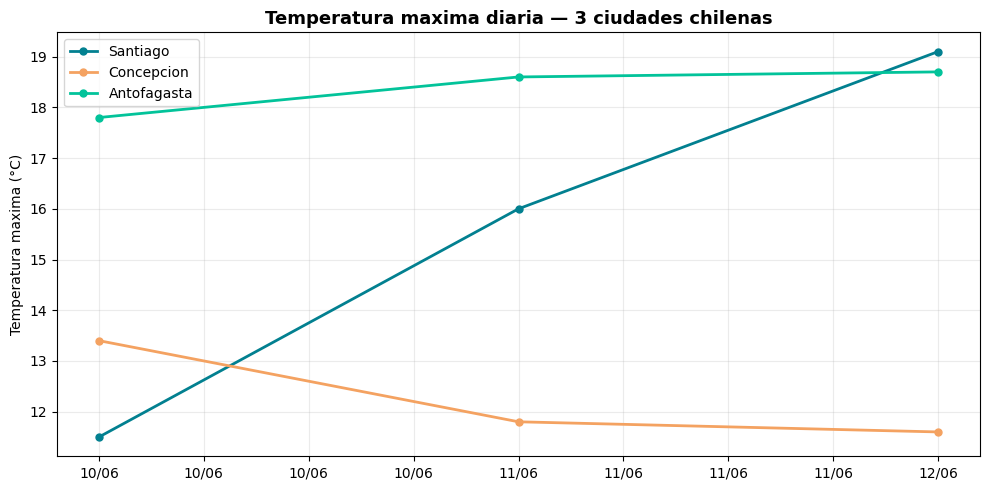

Grafico guardado: comparacion_temp.png


In [50]:
#paso3 
# Load 
resumen_diario.to_csv("resumen_clima.csv", index=False)
print("\nCSV exportado: resumen_clima.csv")

# Visualizar 
fig, ax = plt.subplots(figsize=(10, 5))
colores = ["#028090", "#F4A261", "#02C39A"]

for (ciudad, color) in zip(CIUDADES.keys(), colores):
    df_c = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])
    ax.plot(fechas, df_c["temp_max"], marker="o", label=ciudad,
            color=color, linewidth=2, markersize=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_title("Temperatura maxima diaria — 3 ciudades chilenas", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatura maxima (°C)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: comparacion_temp.png")

Preguntas de reflexion
¿Por qué es importante llamar plt.tight_layout() antes de savefig()?

Es indispensable porque ajusta automáticamente los márgenes internos de la figura. Esto evita que las etiquetas de los ejes (como las fechas en el eje X) o el título del gráfico se corten o queden superpuestos al momento de exportar la imagen a un formato persistente (.png).

¿Cómo modificarías el código para agregar una cuarta ciudad sin cambiar la estructura principal?

Bastaría con añadir una nueva línea dentro del diccionario CIUDADES declarando su clave y su tupla de coordenadas geográficas. Por ejemplo, al agregar "Talca": (-35.43, -71.66), el ciclo for de extracción, el pipeline de consolidación y el bucle de renderizado gráfico la procesarían automáticamente sin alterar una sola línea de código lógico.

Describe el pipeline ETL que implementaste en esta actividad con tus propias palabras.

Extracción (Extract): Se consultó de manera automatizada y segura la API de Open-Meteo para obtener las series de tiempo meteorológicas de tres puntos geográficos diferenciados mediante solicitudes HTTP ordenadas.

Transformación (Transform): Los diccionarios JSON individuales se convirtieron en estructuras tabulares de Pandas, se concatenaron en una gran matriz de datos y se segmentaron por su componente temporal con .dt.date y .agg() para sintetizar las lecturas diarias.

Carga (Load): La información procesada y depurada se consolidó físicamente en un archivo resumen_clima.csv y se proyectó de manera visual a través de una gráfica lineal comparativa de alta calidad.